Using device: mps
combined_indices shape: 6557
to show the differences
-111.0 110.0


/var/folders/1f/9_2wggdd2ygfkk69t5zj8cyh0000gr/T/ipykernel_7147/2744556892.py:260: RuntimeWarning: invalid value encountered in scalar divide
  if mean_pooled[i, j] / max_pooled[i, j] > q1[i, j] / lb[i, j]:


Discord anomaly overlay saved to: anomaly.png


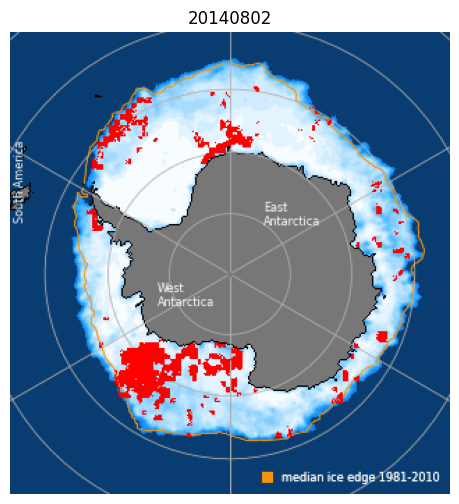

In [5]:
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ============================================================
# CONFIG
# ============================================================
device1 = "mps" 
print("Using device:", device1)

# Expected grayscale size BEFORE padding
H, W = 332, 316   # Your usual size (so padded becomes 334 x 318)

# ============================================================
# 1. INDEX MAPPING (BACKTRACK TO ORIGINAL PIXELS)
# ============================================================

def getIndices(x, kernel_size_h, kernel_size_w, stride_h, stride_w):
    """
    For each (i,j) pooling cell, return 4 corner indices in the input x.
    """
    indices = {}
    h_out = (x.size(0) - kernel_size_h) // stride_h + 1
    w_out = (x.size(1) - kernel_size_w) // stride_w + 1

    for i in range(h_out):
        for j in range(w_out):
            start_i = i * stride_h
            start_j = j * stride_w
            end_i = start_i + kernel_size_h
            end_j = start_j + kernel_size_w

            indices[(i, j)] = [
                (start_i, start_j),               # top-left
                (start_i, end_j - 1),             # top-right
                (end_i - 1, start_j),             # bottom-left
                (end_i - 1, end_j - 1)            # bottom-right
            ]
    return indices


def get_combined_indices_on_gpu(x, y, kernel_size_h, kernel_size_w, stride_h, stride_w):
    """
    Build combined mapping from 2-level pooling:
    (83,79) pooled cells → 16 (4x4) original padded pixel coordinates.
    """
    # First-level indices on padded original
    indices1 = getIndices(x, kernel_size_h, kernel_size_w, stride_h, stride_w)
    # Second-level indices on y
    indices2 = getIndices(y, kernel_size_h, kernel_size_w, stride_h, stride_w)

    combined_indices = {}
    for key2, value2 in indices2.items():
        temp_dict = {}
        for idx in value2:
            temp_dict[idx] = indices1[idx]
        combined_indices[key2] = temp_dict

    return combined_indices


def getIndices_in_orginal_gray(row, col, combined_indices):
    """
    From pooled cell (row,col) → list of 16 original padded indices.
    """
    indices_list_gray_image = [
        index for sublist in combined_indices[(row, col)].values() for index in sublist
    ]
    return indices_list_gray_image


# Precompute combined_indices once (depends only on geometry)
x_template = torch.arange(0, H * W, dtype=torch.float).reshape(H, W)
padded_x_template = F.pad(x_template, (1, 1, 1, 1), 'constant', 0)  # 334x318

y_template = F.avg_pool2d(
    padded_x_template.unsqueeze(0).unsqueeze(0),
    kernel_size=(2, 2),
    stride=(2, 2)
).squeeze()  # 167 x 159

combined_indices_gpu = get_combined_indices_on_gpu(
    padded_x_template, y_template, 2, 2, 2, 2
)
print("combined_indices shape:", len(combined_indices_gpu))  # should be 83*79


# ============================================================
# 2. BASIC BUILDING BLOCKS
# ============================================================

def rgb_to_gray_image_two_files(img1_path, img2_path):
    """
    Read two RGB images, convert to grayscale tensors (H,W) on GPU,
    and original RGB second image (for overlay).
    """
    img1_rgb = cv2.imread(img1_path)
    img2_rgb = cv2.imread(img2_path)

    if img1_rgb is None or img2_rgb is None:
        raise ValueError("Error reading one of the input images.")

    # Resize to expected size if necessary
    img1_rgb = cv2.resize(img1_rgb, (W, H))
    img2_rgb = cv2.resize(img2_rgb, (W, H))

    img1_gray = cv2.cvtColor(img1_rgb, cv2.COLOR_BGR2GRAY)
    img2_gray = cv2.cvtColor(img2_rgb, cv2.COLOR_BGR2GRAY)

    # To tensors
    img1_gray_t = torch.tensor(img1_gray, device=device1, dtype=torch.float32)
    img2_gray_t = torch.tensor(img2_gray, device=device1, dtype=torch.float32)
    img2_rgb_t = torch.tensor(img2_rgb, device=device1, dtype=torch.float32)

    return [img1_gray_t, img2_gray_t], img2_rgb_t


def file_to_gray_padded(gray_image_list, index_no):
    """
    Take gray_image_list[index_no] → pad with 1 pixel border (0).
    """
    gray_image = gray_image_list[index_no].to(device=device1, dtype=torch.float32)
    padded_gray_image = F.pad(gray_image, (1, 1, 1, 1), 'constant', 0)
    return padded_gray_image  # (334,318)


def getKernel(input_tensor):
    """
    For now, kernel is 2x2 ones (like your code).
    """
    result_df = torch.ones((2, 2), device=device1, dtype=torch.float32)
    return result_df


def get_diff_gray_image_kernel_list_gpu(gray_image_list):
    """
    Compute diff between image 2 and image 1, plus a kernel for that diff.
    """
    diff_gray_image_list = []
    diff_gray_image_kernel_list_2_2 = []

    for i in range(len(gray_image_list) - 1):
        arr_gpu = (
            gray_image_list[i + 1].to(device1, dtype=torch.float32)
            - gray_image_list[i].to(device1, dtype=torch.float32)
        )
        diff_gray_image_list.append(arr_gpu)

        kernel_arr_gpu = getKernel(arr_gpu)
        diff_gray_image_kernel_list_2_2.append(kernel_arr_gpu)

    return diff_gray_image_list, diff_gray_image_kernel_list_2_2


def apply_3x3_sharpening(input_tensor, kernel):
    """
    Convolution with 2x2 kernel, stride 2, padding 1 (like your original).
    Input:  (332x316)
    Output: (167x159)
    """
    if isinstance(input_tensor, torch.Tensor):
        in_t = input_tensor.clone().detach().unsqueeze(0).unsqueeze(0).float().to(device1)
    else:
        in_t = torch.tensor(input_tensor, device=device1).unsqueeze(0).unsqueeze(0).float()

    kernel_tensor = kernel.unsqueeze(0).unsqueeze(0).float().to(device1)

    kernel_row, kernel_col = kernel_tensor.shape[-2], kernel_tensor.shape[-1]

    conv_layer = nn.Conv2d(
        in_channels=1,
        out_channels=1,
        kernel_size=(kernel_row, kernel_col),
        stride=(2, 2),
        padding=1,
        bias=False
    ).to(device1)

    conv_layer.weight.data = kernel_tensor
    output = conv_layer(in_t)

    return output[0, 0].detach().cpu().numpy()  # (167,159)


def get_kernel_applied_result_in_diff_gray_image_gpu(diff_gray_image_list, diff_gray_image_kernel_list_2_2):
    kernel_applied_result_in_diff_gray_image = []

    for i in range(len(diff_gray_image_list)):
        matrix = diff_gray_image_list[i]
        kernel = diff_gray_image_kernel_list_2_2[i]

        result = apply_3x3_sharpening(matrix, kernel)  # numpy (167x159)
        kernel_applied_result_in_diff_gray_image.append(result)

    return kernel_applied_result_in_diff_gray_image


# ============================================================
# 3. POOLING + CMAD DISCORD DETECTION
# ============================================================

def pooling(input_matrix, pool_height, pool_width, stride_height, stride_width, pool_type):
    """
    Your original pooling definition (negative max, mean).
    """
    if pool_type == 'max':
        input_matrix1 = torch.tensor(input_matrix, device=device1)

        input_matrix2 = torch.where(input_matrix1 > 0, torch.tensor(0.0, device=device1), input_matrix1)
        input_matrix3 = torch.abs(input_matrix2)

        input_tensor = input_matrix3.unsqueeze(0).unsqueeze(0)

        max_pool = nn.MaxPool2d(kernel_size=(pool_height, pool_width),
                                stride=(stride_height, stride_width))

        return_max = max_pool(input_tensor)[0][0].cpu().detach().numpy()
        return -1.0 * return_max

    elif pool_type == 'mean':
        input_tensor = torch.tensor(input_matrix, device=device1)
        input_tensor = input_tensor.unsqueeze(0).unsqueeze(0)

        mean_pool = nn.AvgPool2d(kernel_size=(pool_height, pool_width),
                                 stride=(stride_height, stride_width))

        return mean_pool(input_tensor)[0][0].cpu().detach().numpy()


def detect_discord_anomaly(matrix, lb, q1, gray_padded_first,gray_padded_second):
    """
    Implements your 'discord' condition only:
    if max_pooled < lb and (mean/max) > (q1/lb) → anomaly.
    Backtracks pixels using combined_indices_gpu.
    """
    r, c = 2, 2

    gray_padded = gray_padded_second - gray_padded_first  # use second image for anomaly pixel values

    print('to show the differences')


    print(np.min(gray_padded.cpu().numpy()), np.max(gray_padded.cpu().numpy()))

    max_pooled = pooling(matrix, pool_height=r, pool_width=c,
                         stride_height=r, stride_width=c, pool_type='max')
    mean_pooled = pooling(matrix, pool_height=r, pool_width=c,
                          stride_height=r, stride_width=c, pool_type='mean')

    rows, cols = mean_pooled.shape  # should be (83,79)

    anomaly_array = torch.zeros_like(gray_padded, device=device1)

    for i in range(rows):
        for j in range(cols):
            if max_pooled[i, j] < lb[i, j]:
                if mean_pooled[i, j] / max_pooled[i, j] > q1[i, j] / lb[i, j]:
                    indices_list = getIndices_in_orginal_gray(i, j, combined_indices_gpu)
                    for (rowIndex, colIndex) in indices_list:

                        if(gray_padded[rowIndex, colIndex] <0):
                            anomaly_array[rowIndex, colIndex] = 1

    # Remove padding → back to 332x316
    anomaly_array = anomaly_array[1:-1, 1:-1]

    return anomaly_array  # torch (332,316)


# ============================================================
# 4. MAIN FUNCTION: TWO IMAGES → DISCORD OVERLAY
# ============================================================

import os

def extract_date(path):
    return os.path.splitext(os.path.basename(path))[0]

def cmad_discord_for_two_images(
    img1_path,
    img2_path,
    lb_txt_path="lb.txt",
    q1_txt_path="q1.txt",
    show_plot=True,
    save_path="discord_overlay.png"
):
    # ---- Load thresholds ----
    lb = np.loadtxt(lb_txt_path)  # shape (83,79)
    q1 = np.loadtxt(q1_txt_path)  # shape (83,79)

    if lb.shape != (83, 79) or q1.shape != (83, 79):
        raise ValueError(f"LB/Q1 shape mismatch, expected (83,79), got {lb.shape}, {q1.shape}")

    # ---- Load images, compute diff & kernel convolution ----
    gray_image_list, img2_rgb_t = rgb_to_gray_image_two_files(img1_path, img2_path)

    padded_gray_second = file_to_gray_padded(gray_image_list, 1)  # second image, padded
    padded_gray_first = file_to_gray_padded(gray_image_list, 0)   # first image, padded

    diff_gray_image_list, diff_kernel_list = get_diff_gray_image_kernel_list_gpu(gray_image_list)
    kernel_applied_list = get_kernel_applied_result_in_diff_gray_image_gpu(diff_gray_image_list, diff_kernel_list)
    matrix = kernel_applied_list[0]  # (167,159) for this pair

    # ---- Detect discord anomaly ----
    anomaly_array = detect_discord_anomaly(matrix, lb, q1, padded_gray_first,padded_gray_second)  # torch (332,316)

    anomaly_np = anomaly_array.cpu().numpy()
    anomaly_mask = anomaly_np > 0  # boolean mask

    # ---- Overlay anomalies on second RGB image ----
    img2_rgb = img2_rgb_t.cpu().numpy().astype(np.uint8)  # (332,316,3) BGR
    overlay = img2_rgb.copy()

    # Color anomalies in red (BGR = [0,0,255])
    overlay[anomaly_mask] = [0, 0, 255]

    # Save overlay
    cv2.imwrite(save_path, overlay)
    print(f"Discord anomaly overlay saved to: {save_path}")

    date_str = extract_date(img2_path)

    # Show with matplotlib (convert BGR→RGB)
    if show_plot:
        overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)

        plt.figure(figsize=(8, 6))
        plt.imshow(overlay_rgb)
        plt.title(str(date_str))
        plt.axis("off")
        plt.show()

    return anomaly_mask, overlay


# ============================================================
# 5. EXAMPLE USAGE
# ============================================================

    # Replace these with your image + txt paths
img1_path = "/Users/maloyd1/Maloy_everything/CMAD/Melting/aug-feb(AM)/2014/20140801.png"   # older date
img2_path = "/Users/maloyd1/Maloy_everything/CMAD/Melting/aug-feb(AM)/2014/20140802.png"   # newer date

lb_txt_path = "lb15.txt"
q1_txt_path = "q115.txt"

anomaly_mask, overlay = cmad_discord_for_two_images(
    img1_path,
    img2_path,
    lb_txt_path,
    q1_txt_path,
    show_plot=True,
    save_path="anomaly.png"
)
